# 07 — Dataset Validation

**Goal:**  
Validate the structural and semantic integrity of the YOLO dataset before training.

**This notebook will:**
1. Verify image ↔ label correspondence  
2. Check YOLO label format consistency (`cls xc yc w h`)  
3. Analyze bounding box size statistics  
4. Display random visual examples with drawn boxes  
5. Report missing, invalid, or corrupted files  

**Output:**  
Visualizations in `images_with_boxes/` and a summary validation report.

**Based on:** `test_labels.py`

In [2]:
# === Imports ===
import os
import cv2
import yaml
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# === Import shared config ===
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from config import OUTPUT_DIR, CLASSES, IMG_EXT, IMG_WIDTH, IMG_HEIGHT, TRAIN_SPLIT

# === Configuration ===
DATASET_DIR = OUTPUT_DIR   # dataset created during generation
SPLIT = "train"            # can be "train" or "val"
RESULTS_DIR = "./validation_outputs"
REPORTS_DIR = "./validation_reports"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"✅ Dataset directory: {DATASET_DIR}")
print(f"✅ Split: {SPLIT}")
print(f"✅ Classes: {CLASSES}")

✅ Dataset directory: ./data/epic_train_subset
✅ Split: train
✅ Classes: ['bread', 'knife', 'cheese', 'ham', 'tomato', 'cucumber', 'carrot', 'butter']


## Step 1 — Load dataset.yaml and verify structure

In [3]:
yaml_path = os.path.join(DATASET_DIR, "dataset.yaml")
if not os.path.exists(yaml_path):
    raise FileNotFoundError(f"dataset.yaml not found in {DATASET_DIR}")

with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg.get("names", [])
nc = len(names)
print(f"✅ {nc} classes detected: {names}")

# Paths
img_dir = os.path.join(DATASET_DIR, SPLIT, "images")
lbl_dir = os.path.join(DATASET_DIR, SPLIT, "labels")

if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
    raise FileNotFoundError("Image or label directories not found in dataset structure.")

# Assign colors for visualization
colors = {i: [random.randint(0, 255) for _ in range(3)] for i in range(nc)}

✅ 2 classes detected: ['bread', 'knife']


## Step 2 — Verify Image ↔ Label Correspondence

In [4]:
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXT)]
label_files = [f for f in os.listdir(lbl_dir) if f.lower().endswith(".txt")]

img_basenames = {os.path.splitext(f)[0] for f in image_files}
lbl_basenames = {os.path.splitext(f)[0] for f in label_files}

missing_labels = sorted(list(img_basenames - lbl_basenames))
missing_images = sorted(list(lbl_basenames - img_basenames))

print(f"📸 Total images: {len(image_files)}")
print(f"🧾 Total labels: {len(label_files)}")
print(f"⚠️ Missing labels: {len(missing_labels)} | ⚠️ Missing images: {len(missing_images)}")

# Save report
if missing_labels or missing_images:
    with open(os.path.join(REPORTS_DIR, "missing_files.txt"), "w") as f:
        f.write("Missing Labels:\n")
        f.writelines([m + "\n" for m in missing_labels])
        f.write("\nMissing Images:\n")
        f.writelines([m + "\n" for m in missing_images])
    print(f"📄 Report saved in {REPORTS_DIR}/missing_files.txt")

📸 Total images: 164
🧾 Total labels: 164
⚠️ Missing labels: 0 | ⚠️ Missing images: 0


## Step 3 — Validate YOLO Label Format
Ensures all labels have 5 values and normalized coordinates between 0 and 1.

In [5]:
invalid_lines = []
bbox_stats = []

for lbl_file in tqdm(label_files, desc="Validating labels"):
    lbl_path = os.path.join(lbl_dir, lbl_file)
    with open(lbl_path, "r") as f:
        for line_num, line in enumerate(f.readlines(), 1):
            parts = line.strip().split()
            if len(parts) != 5:
                invalid_lines.append((lbl_file, line_num, line.strip()))
                continue
            try:
                cls_id, xc, yc, bw, bh = map(float, parts)
                if cls_id < 0 or cls_id >= nc or not (0 < bw <= 1 and 0 < bh <= 1):
                    invalid_lines.append((lbl_file, line_num, line.strip()))
                else:
                    bbox_stats.append([cls_id, bw, bh])
            except ValueError:
                invalid_lines.append((lbl_file, line_num, line.strip()))

if invalid_lines:
    pd.DataFrame(invalid_lines, columns=["file", "line", "content"]).to_csv(
        os.path.join(REPORTS_DIR, "invalid_labels.csv"), index=False)
    print(f"⚠️ {len(invalid_lines)} invalid lines found. See {REPORTS_DIR}/invalid_labels.csv")
else:
    print("✅ All label files are correctly formatted.")

Validating labels: 100%|██████████| 164/164 [00:00<00:00, 7309.71it/s]

✅ All label files are correctly formatted.


## Step 4 — Analyze Bounding Box Statistics

📈 182 total bounding boxes
Mean width: 0.159 | Mean height: 0.295
Aspect ratio mean: 0.643


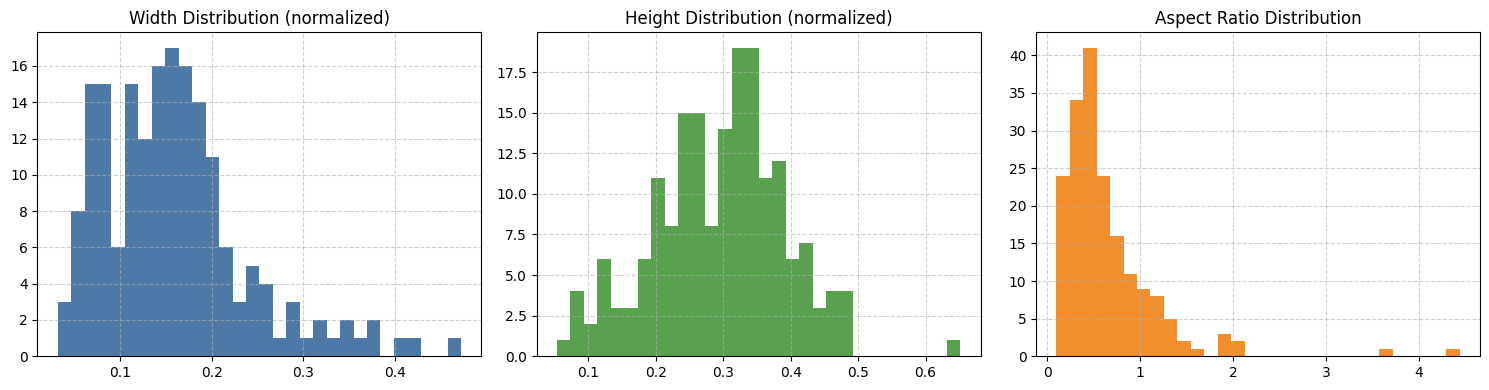

In [6]:
if len(bbox_stats) > 0:
    bbox_stats = np.array(bbox_stats)
    widths, heights = bbox_stats[:, 1], bbox_stats[:, 2]
    aspect_ratios = widths / heights

    print(f"📈 {len(bbox_stats)} total bounding boxes")
    print(f"Mean width: {np.mean(widths):.3f} | Mean height: {np.mean(heights):.3f}")
    print(f"Aspect ratio mean: {np.mean(aspect_ratios):.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(widths, bins=30, color="#4e79a7")
    axes[0].set_title("Width Distribution (normalized)")
    axes[1].hist(heights, bins=30, color="#59a14f")
    axes[1].set_title("Height Distribution (normalized)")
    axes[2].hist(aspect_ratios, bins=30, color="#f28e2b")
    axes[2].set_title("Aspect Ratio Distribution")
    for ax in axes: ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid bounding boxes found for analysis.")

## Step 5 — Visual Inspection of Random Samples

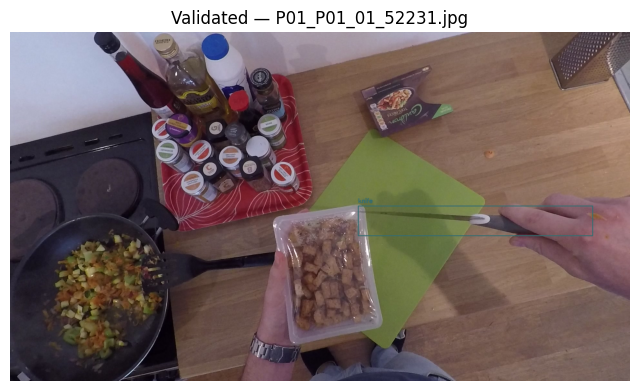

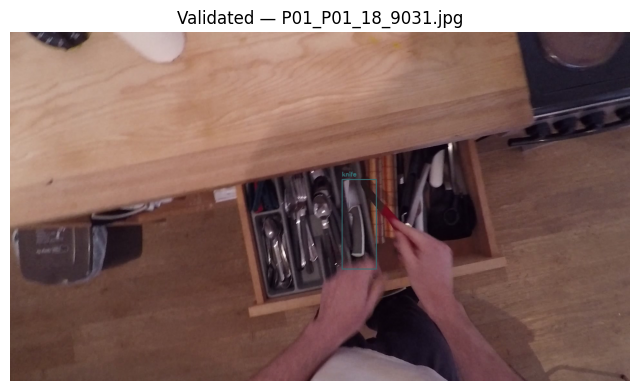

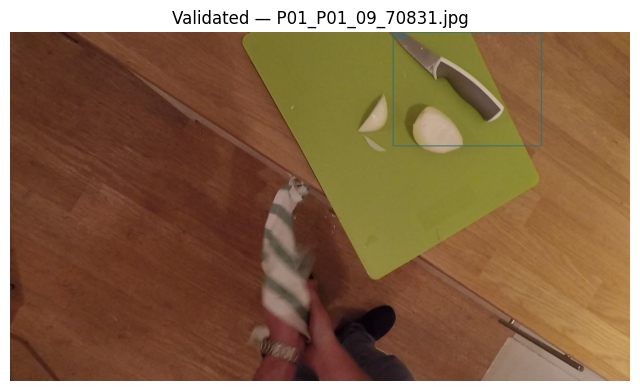

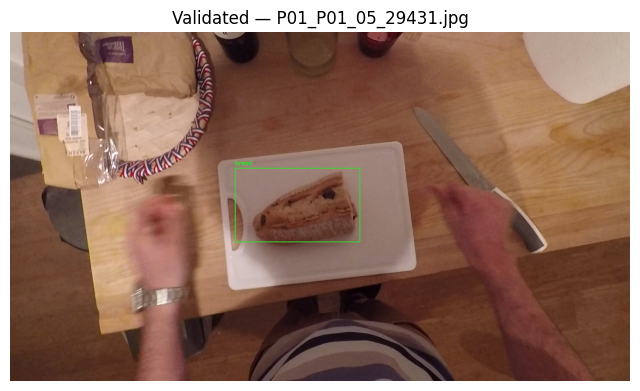

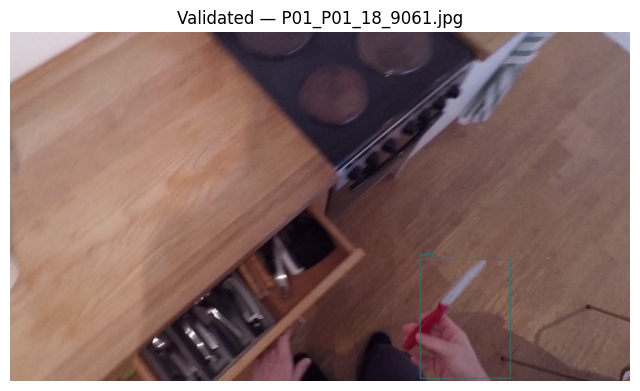

✅ Annotated examples saved to: ./validation_outputs


In [7]:
sample_images = random.sample(image_files, min(5, len(image_files)))

for img_file in sample_images:
    img_path = os.path.join(img_dir, img_file)
    lbl_path = os.path.join(lbl_dir, os.path.splitext(img_file)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id, xc, yc, bw, bh = map(float, parts)
                cls_id = int(cls_id)
                x_c, y_c, bw, bh = xc * w, yc * h, bw * w, bh * h
                x1, y1 = int(x_c - bw / 2), int(y_c - bh / 2)
                x2, y2 = int(x_c + bw / 2), int(y_c + bh / 2)

                color = colors.get(cls_id, (255, 255, 255))
                class_name = names[cls_id] if cls_id < len(names) else f"id {cls_id}"

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, class_name, (x1, max(20, y1 - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out_path = os.path.join(RESULTS_DIR, img_file)
    cv2.imwrite(out_path, img)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Validated — {img_file}")
    plt.axis("off")
    plt.show()

print(f"✅ Annotated examples saved to: {RESULTS_DIR}")

## ✅ Step 6 — Validation Summary

**Checks performed:**
- Image ↔ Label consistency ✅  
- YOLO format structure ✅  
- Bounding box statistics ✅  
- Visual inspection ✅  

**Generated Reports:**
- `validation_reports/missing_files.txt`  
- `validation_reports/invalid_labels.csv`  

**Visual Outputs:**  
`validation_outputs/` — annotated sample images.

This ensures your dataset is ready for reliable training and fine-tuning.